# exp004 Feature Engineering v2

## 0. Experiment Metadata

In [1]:
# ========================================
# EXPERIMENT CONFIG
# ========================================

EXP_NAME = "exp004_feature_engineering_v2"
TARGET = "Churn"
ID_COL = "id"

N_SPLITS = 5
SEED = 42

print(f"Running {EXP_NAME}")

Running exp004_feature_engineering_v2


## 1. Imports

In [2]:
# ========================================
# IMPORTS
# ========================================

import os
import random
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

import lightgbm as lgb

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',50)

## 2. Reproducibility

In [3]:
# ========================================
# SEED EVERYTHING
# ========================================

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(SEED)

## 3. Load Data

In [21]:
# ========================================
# LOAD DATA
# ========================================

DATA_PATH = "/Users/theojeremiah/Workspace/01_DataScience/Projects/202603_Kaggle_CustomerChurn/data/raw/"

train = pd.read_csv(DATA_PATH + "train.csv")
test = pd.read_csv(DATA_PATH + "test.csv")

print(train.shape, test.shape)
train.head()

(594194, 21) (254655, 20)


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


## 4. Quick Sanity Checs (Fast EDA)

In [22]:
# ========================================
# QUICK EDA
# ========================================

print("Target distribution:")
print(train['Churn'].value_counts(normalize=True))

print("\nMissing values (top 10):")
print(train.isnull().mean().sort_values(ascending=False).head(10))

Target distribution:
Churn
No     0.774792
Yes    0.225208
Name: proportion, dtype: float64

Missing values (top 10):
id                  0.0
DeviceProtection    0.0
TotalCharges        0.0
MonthlyCharges      0.0
PaymentMethod       0.0
PaperlessBilling    0.0
Contract            0.0
StreamingMovies     0.0
StreamingTV         0.0
TechSupport         0.0
dtype: float64


### Auto EDA

In [8]:
# ========================================
# AUTO EDA REPORT
# ========================================

from ydata_profiling import ProfileReport

profile = ProfileReport(
    train,
    title="Churn Dataset Profiling",
    explorative=True
)

profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|███████████████████████████████████████████████████████████████████████████████████| 21/21 [00:03<00:00,  5.56it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

## 5. Feature Engineering 

In [23]:
# ========================================
# FEATURE ENGINEERING (EXP004 - REFINED)
# ========================================

service_cols = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]

def create_features(df, ref_df=None):
    df = df.copy()
    
    # Use train as reference for consistent stats
    if ref_df is None:
        ref_df = df

    # ========================================
    # REMOVE REDUNDANT RAW FEATURES
    # ========================================
    if "TotalCharges" in df.columns:
        df = df.drop(columns=["TotalCharges"])

    # ========================================
    # CORE NUMERIC FEATURE
    # ========================================
    if "MonthlyCharges" in df.columns and "tenure" in df.columns:
        df["usage_velocity"] = df["MonthlyCharges"] / (df["tenure"] + 1)

    # ========================================
    # 1. RELATIVE CHARGE (STRONG SIGNAL)
    # ========================================
    if "MonthlyCharges" in df.columns:
        mean_charge = ref_df["MonthlyCharges"].mean()
        df["charge_vs_avg"] = df["MonthlyCharges"] / mean_charge

    # ========================================
    # 2. TENURE PERCENTILE (BETTER THAN BINNING)
    # ========================================
    if "tenure" in df.columns:
        df["tenure_pct"] = df["tenure"].rank(pct=True)

    # ========================================
    # 3. SERVICE COUNT (clean version)
    # ========================================
    if all(col in df.columns for col in service_cols):
        df["num_services"] = (df[service_cols] == "Yes").sum(axis=1)

    # ========================================
    # 4. CHARGE PER SERVICE (VERY STRONG)
    # ========================================
    if "MonthlyCharges" in df.columns and "num_services" in df.columns:
        df["charge_per_service"] = df["MonthlyCharges"] / (df["num_services"] + 1)

    # ========================================
    # 5. SUPPORT FEATURE (KEEP)
    # ========================================
    if "OnlineSecurity" in df.columns and "TechSupport" in df.columns:
        df["has_support"] = (
            (df["OnlineSecurity"] == "Yes") |
            (df["TechSupport"] == "Yes")
        ).astype(int)

    # ========================================
    # 6. CONTINUOUS INTERACTION (BETTER VERSION)
    # ========================================
    if "MonthlyCharges" in df.columns and "tenure" in df.columns:
        df["charge_tenure_interaction"] = (
            df["MonthlyCharges"] * np.log1p(df["tenure"])
        )

    # ========================================
    # 7. IMPROVED INTERACTION (replace binary)
    # ========================================
    if "MonthlyCharges" in df.columns and "tenure" in df.columns:
        median_charge = ref_df["MonthlyCharges"].median()
        df["high_charge_new"] = (
            (df["MonthlyCharges"] > median_charge) &
            (df["tenure"] < 12)
        ).astype(int)

    return df


# Apply (IMPORTANT: use train as reference)
train = create_features(train, ref_df=train)
test = create_features(test, ref_df=train)

In [24]:
# ========================================
# REMOVE REDUNDANT FEATURES (LOGIC-BASED)
# ========================================

DROP_COLS = [
    "tenure",
    "MonthlyCharges"
]

train = train.drop(columns=[col for col in DROP_COLS if col in train.columns])
test = test.drop(columns=[col for col in DROP_COLS if col in test.columns])

## 6. Encoding

In [25]:
# ========================================
# TARGET ENCODING (SIMPLE VERSION)
# ========================================

from category_encoders import TargetEncoder

# Get categorical columns from TRAIN
categorical_cols = train.select_dtypes(include="object").columns.tolist()

# Remove target column
categorical_cols = [col for col in categorical_cols if col != TARGET]

# Initialize encoder
encoder = TargetEncoder(cols=categorical_cols)

# Fit on train, transform both
train[categorical_cols] = encoder.fit_transform(train[categorical_cols], train[TARGET])
test[categorical_cols] = encoder.transform(test[categorical_cols])

In [32]:
train.head()

,id,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn,usage_velocity,charge_vs_avg,tenure_pct,num_services,charge_per_service,has_support,charge_tenure_interaction,high_charge_new
0,0,0.222348,0,0.133796,0.072796,0.22892,0.182322,0.103064,0.086821,0.391026,0.182658,0.096467,0.297416,0.299299,0.057628,0.319387,0.079697,No,2.003333,0.912456,0.447214,3,15.025,1,204.411963,0
1,1,0.222348,0,0.133796,0.072796,0.22892,0.182322,0.103064,0.086821,0.167240,0.380630,0.096467,0.284660,0.299299,0.009982,0.074606,0.069332,No,1.177966,1.055169,0.712218,4,13.900,1,283.388852,0
2,2,0.222348,0,0.133796,0.291354,0.22892,0.277026,0.415366,0.406133,0.167240,0.380630,0.401620,0.284660,0.283066,0.420543,0.319387,0.489052,No,1.701695,1.524302,0.712218,3,25.100,0,409.384759,0
3,3,0.228036,0,0.324621,0.291354,0.22892,0.182322,0.415366,0.406133,0.391026,0.380630,0.401620,0.297416,0.299299,0.420543,0.319387,0.489052,Yes,34.850000,1.058206,0.024557,0,69.700,0,48.312358,0
4,4,0.228036,0,0.324621,0.291354,0.22892,0.182322,0.415366,0.406133,0.391026,0.380630,0.401620,0.297416,0.299299,0.420543,0.319387,0.489052,Yes,35.225000,1.069592,0.024557,0,70.450,0,48.832219,0


## 7. Prepare Data

In [26]:
# ========================================
# PREPARE DATA
# ========================================

features = [col for col in train.columns if col not in [TARGET, ID_COL]]

X = train[features]
y = train[TARGET]

X_test = test[features]

## 8. Validation Strategy

In [27]:
# ========================================
# CV SETUP
# ========================================

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED
)

## 9. Model Training

In [28]:
# ========================================
# TRAINING LOOP + OOF
# ========================================

oof_preds = np.zeros(len(train))
test_preds = np.zeros(len(test))

scores = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    
    print(f"\n--- Fold {fold} ---")
    
    X_train, X_valid = X.iloc[tr_idx], X.iloc[val_idx]
    y_train, y_valid = y.iloc[tr_idx], y.iloc[val_idx]

    model = lgb.LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=31,
        random_state=SEED
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        callbacks=[
            lgb.early_stopping(50),
            lgb.log_evaluation(100)
        ]
    )

    # Validation predictions (OOF)
    val_preds = model.predict_proba(X_valid)[:, 1]
    oof_preds[val_idx] = val_preds

    # Test predictions
    test_preds += model.predict_proba(X_test)[:, 1] / N_SPLITS

    score = roc_auc_score(y_valid, val_preds)
    scores.append(score)

    print(f"Fold {fold} AUC: {score:.5f}")

print("\nCV Mean:", np.mean(scores))
print("CV Std:", np.std(scores))


--- Fold 0 ---
[LightGBM] [Info] Number of positive: 107054, number of negative: 368301
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005957 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1162
[LightGBM] [Info] Number of data points in the train set: 475355, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.225209 -> initscore=-1.235567
[LightGBM] [Info] Start training from score -1.235567
Training until validation scores don't improve for 50 rounds
[100]	valid_0's binary_logloss: 0.304208
[200]	valid_0's binary_logloss: 0.302991
[300]	valid_0's binary_logloss: 0.302785
[400]	valid_0's binary_logloss: 0.302727
Early stopping, best iteration is:
[353]	valid_0's binary_logloss: 0.302702
Fold 0 AUC: 0.91334

--- Fold 1 ---
[LightGBM] [Info] Number of positive: 107054, number of negative: 368301
[LightGBM] [I

## Shap Explainability


Training final model on FULL data for SHAP...
[LightGBM] [Info] Number of positive: 133817, number of negative: 460377
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007098 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1162
[LightGBM] [Info] Number of data points in the train set: 594194, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.225208 -> initscore=-1.235573
[LightGBM] [Info] Start training from score -1.235573
Calculating SHAP values...
Plotting SHAP summary...


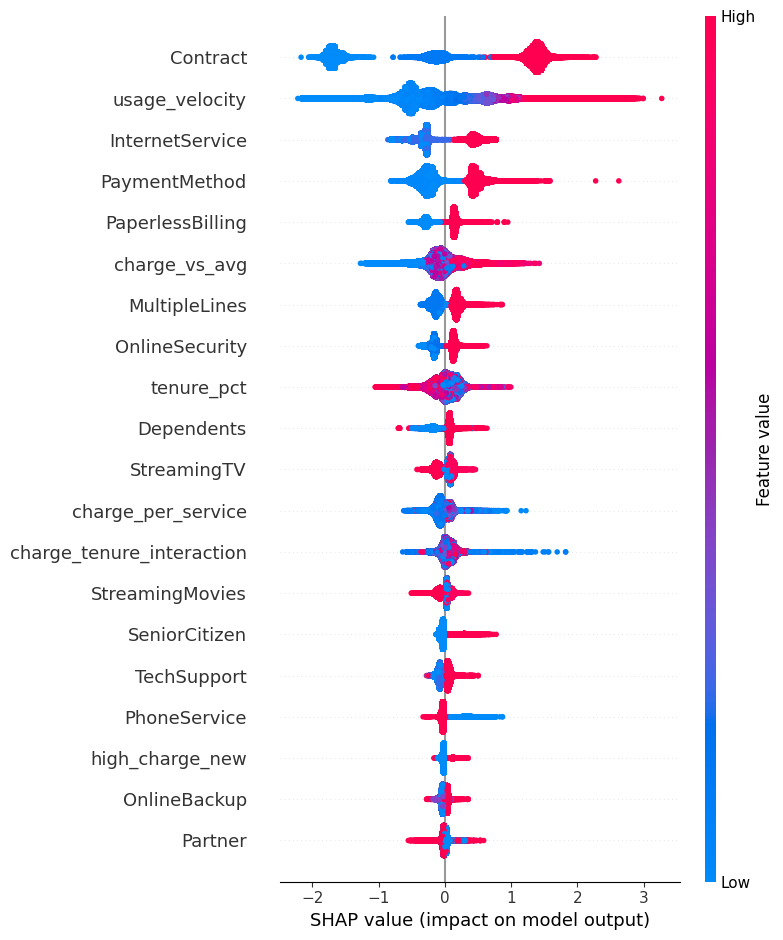

Creating SHAP importance table...

Top 20 SHAP Features:


,feature,importance
13,Contract,1.251885
16,usage_velocity,0.544559
6,InternetService,0.402318
15,PaymentMethod,0.353400
14,PaperlessBilling,0.205329
17,charge_vs_avg,0.193192
5,MultipleLines,0.159025
7,OnlineSecurity,0.157672
18,tenure_pct,0.135085
3,Dependents,0.111976


In [34]:
import shap
import matplotlib.pyplot as plt

print("\nTraining final model on FULL data for SHAP...")

# Train final model on full dataset
final_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    random_state=SEED
)

final_model.fit(X, y)

# ========================================
# SHAP VALUES
# ========================================

print("Calculating SHAP values...")

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X)

# For binary classification, shap returns list
# Use class 1 (churn)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# ========================================
# SHAP SUMMARY PLOT (GLOBAL IMPORTANCE)
# ========================================

print("Plotting SHAP summary...")

plt.figure()
shap.summary_plot(shap_values, X, show=True)

# ========================================
# SHAP FEATURE IMPORTANCE TABLE
# ========================================

print("Creating SHAP importance table...")

shap_importance = np.abs(shap_values).mean(axis=0)

shap_df = pd.DataFrame({
    "feature": X.columns,
    "importance": shap_importance
}).sort_values(by="importance", ascending=False)

print("\nTop 20 SHAP Features:")
display(shap_df.head(20))

In [35]:
shap_df

,feature,importance
13,Contract,1.251885
16,usage_velocity,0.544559
6,InternetService,0.402318
15,PaymentMethod,0.353400
14,PaperlessBilling,0.205329
17,charge_vs_avg,0.193192
5,MultipleLines,0.159025
7,OnlineSecurity,0.157672
18,tenure_pct,0.135085
3,Dependents,0.111976


## 10. Treshold Optimization

In [36]:
# ========================================
# THRESHOLD OPTIMIZATION (OOF)
# ========================================

from sklearn.metrics import f1_score
import numpy as np

# Make sure y is numeric
y_numeric = y.map({"No": 0, "Yes": 1}) if y.dtype == "object" else y

thresholds = np.arange(0.1, 0.9, 0.01)

best_thresh = 0.5
best_score = 0

for t in thresholds:
    preds_bin = (oof_preds > t).astype(int)
    score = f1_score(y_numeric, preds_bin)

    if score > best_score:
        best_score = score
        best_thresh = t

print("\nBest Threshold:", best_thresh)
print("Best F1 Score:", best_score)


Best Threshold: 0.33999999999999986
Best F1 Score: 0.6981680453451519


## 11. Feature Importance

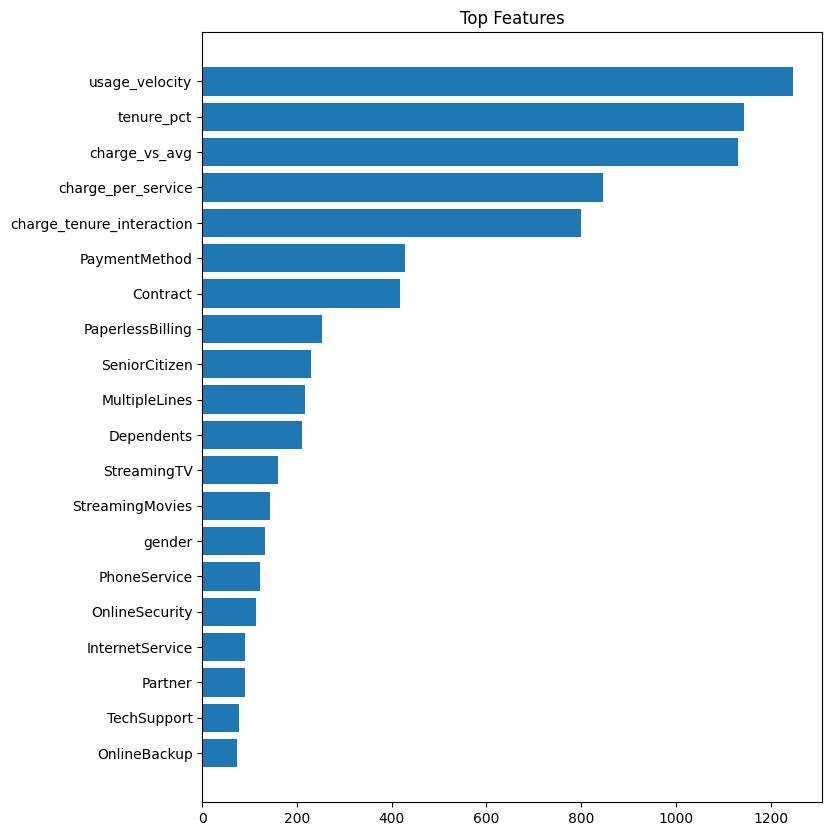

In [30]:
# ========================================
# FEATURE IMPORTANCE
# ========================================

import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

importance.head(20)

plt.figure(figsize=(8, 10))
plt.barh(importance["feature"].head(20), importance["importance"].head(20))
plt.gca().invert_yaxis()
plt.title("Top Features")
plt.show()

## 12. Create Submission

In [31]:
# ========================================
# SUBMISSION (SAVE TO CUSTOM PATH)
# ========================================

import os

# Define path
OUTPUT_DIR = "/Users/theojeremiah/Workspace/01_DataScience/Projects/202603_Kaggle_CustomerChurn/outputs/submissions/"

# Create folder if not exists
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Create submission
submission = pd.DataFrame({
    ID_COL: test[ID_COL],
    TARGET: (test_preds > best_thresh).astype(int)  # or test_preds if using probability
})

# File path
file_path = os.path.join(OUTPUT_DIR, f"{EXP_NAME}.csv")

# Save
submission.to_csv(file_path, index=False)

print(f"Submission saved at: {file_path}")

Submission saved at: /Users/theojeremiah/Workspace/01_DataScience/Projects/202603_Kaggle_CustomerChurn/outputs/submissions/exp004_feature_engineering_v2.csv
